# 3栋1-4单元 + 4栋2单元 喂食数据分析

# 1 数据读取

In [1]:
from src.config.path import PATH_FEED_PROCESSED
import pandas as pd

df_31_col = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-1_column.parquet', engine='pyarrow').drop_duplicates()
df_32_col = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-2_column.parquet', engine='pyarrow').drop_duplicates()
df_33_col = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-3_column.parquet', engine='pyarrow').drop_duplicates()
df_34_col = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-4_column.parquet', engine='pyarrow').drop_duplicates()

df_31_build = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-1_build.parquet', engine='pyarrow').drop_duplicates()
df_32_build = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-2_build.parquet', engine='pyarrow').drop_duplicates()
df_33_build = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-3_build.parquet', engine='pyarrow').drop_duplicates()
df_34_build = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-4_build.parquet', engine='pyarrow').drop_duplicates()

### 单元总量折线图

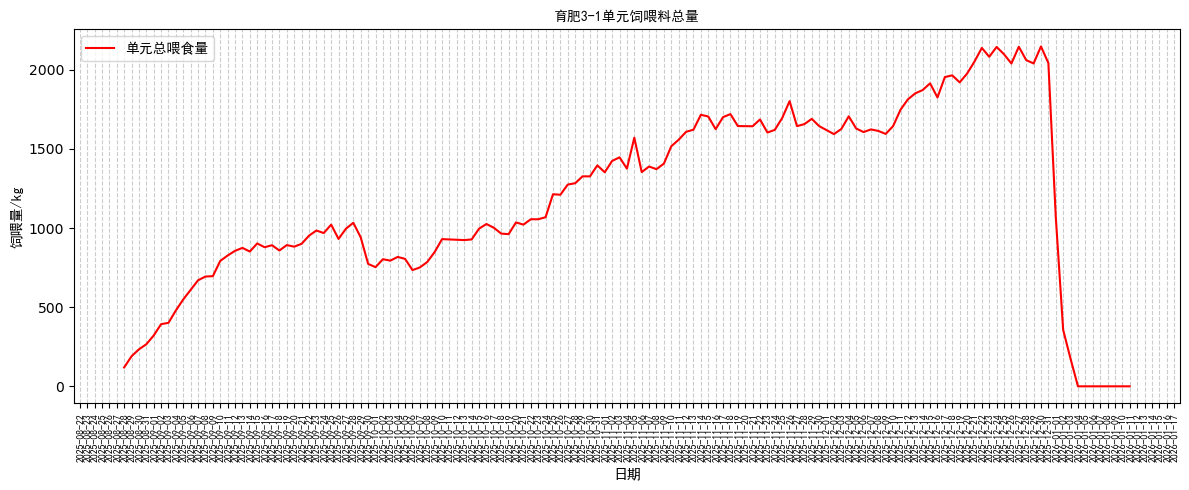

In [2]:
from src.visualization.line_plot import line_static_feed_build
line_static_feed_build(df_31_build, unit="育肥3-1单元")

### 单元总量折线对比

In [3]:
from src.visualization.line_plot import line_dynamic_feed_build

line_dynamic_feed_build([df_31_build, df_32_build, df_33_build, df_34_build], name_list=["育肥3-1单元", "育肥3-2单元", "育肥3-3单元", "育肥3-4单元"])

### 单元各栏折线图

In [4]:
from src.visualization.line_plot import line_dynamic_feed_column

line_dynamic_feed_column(df_31_col, unit="育肥3-1单元", if_partial=True, start_date='2025-8-30', end_date='2025-12-25', save_img=False)

### 单元各栏热力图

In [6]:
from src.visualization.heatmap_plot import prepare_heatmap_dynamic_feed_col, heatmap_dynamic_feed_col

df_31_matrix = prepare_heatmap_dynamic_feed_col(df_31_col, smooth_win=1, lag=1, if_partial=True, start_date='2025-8-31', end_date='2025-12-31')
fig = heatmap_dynamic_feed_col(df_31_matrix, unit="育肥3-1单元", color_max_range=80)

fig.show()